# Lazada Uplift — Làm sạch & Chia dữ liệu

Notebook thứ hai của đề tài. Nhận đầu vào là kết luận từ `01_eda.ipynb`, làm ba việc:

1. **Làm sạch** — áp đúng danh sách 14 cột mà EDA đã chỉ ra, còn lại **69 đặc trưng**
2. **Kiểm tra giả định positivity** bằng propensity score
3. **Cắt dữ liệu** thành 4 tập theo đúng phân chia notebook 01 đã chốt

### Không tạo đặc trưng dẫn xuất

Bản trước có thêm 7 cột `fe_*` (tỉ lệ, tương tác, thống kê theo dòng) dựng trên các cặp cột được chọn bằng mắt. Chúng bị bỏ hẳn, vì ba lý do:

- Dữ liệu ẩn danh hoàn toàn (`f0`…`f82`) nên không có hiểu biết nghiệp vụ nào để biện minh cho việc chọn cặp cột này thay vì cặp khác — việc chọn đó là một quyết định tùy ý nằm ngoài dữ liệu.
- Mô hình cây tự dựng được tương tác giữa các cột; thêm tích và tỉ lệ chỉ làm bảng feature importance khó đọc hơn.
- Mỗi cột dẫn xuất là một công thức phía AI Service phải tính lại đúng lúc phục vụ — thêm một chỗ để lệch giữa huấn luyện và triển khai, đổi lấy phần lợi ích chưa từng đo được.

Vậy **tập đặc trưng đưa vào mô hình đúng bằng 69 cột gốc đã làm sạch**, giữ nguyên thứ tự `f0 → f82`.

### Thiết kế chia dữ liệu

```
full_trainset (926.669 dòng, có bias)
        ├── Train        80%   -> huấn luyện mô hình
        └── Val          20%   -> tinh chỉnh siêu tham số

full_testset  (181.669 dòng, RCT)
        ├── RCT-select   50%   -> chọn quán quân giữa các mô hình
        └── RCT-holdout  50%   -> chạy MỘT lần, ra số báo cáo cuối
```

Lý do tách tập RCT làm đôi: nếu vừa dùng nó để **chọn** mô hình vừa dùng để **báo cáo** kết quả thì con số cuối cùng bị thổi phồng, vì đã chọn ra cái may mắn nhất trên chính tập đó. Tách đôi giúp con số báo cáo trung thực.

Phép chia đã làm xong ở notebook 01, **trước khi** ai nhìn vào dữ liệu. Ở đây chỉ đọc lại và đối chiếu mã băm.

### Đầu ra

4 file parquet trong `dataset/` và `artifacts/feature_info.json`.

---
# Phần 1 — Nạp dữ liệu và kết quả EDA

### Bước 1 — Import thư viện

In [27]:
import os
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

warnings.filterwarnings('ignore')

ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
DATA_DIR = os.path.join(ROOT, 'dataset')
FIG_DIR = os.path.join(ROOT, 'reports', 'figures')
ART_DIR = os.path.join(ROOT, 'artifacts')
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

C_TREAT, C_CTRL, C_ACC = '#d95f02', '#2b5c8f', '#1b9e77'

def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name + '.png'), bbox_inches='tight')

### Bước 2 — Đọc kết quả bàn giao từ notebook 01

Notebook 01 đã ghi ra file JSON chứa danh sách cột cần loại bỏ. Đọc lại thay vì gõ tay, để hai notebook không bao giờ lệch nhau.

In [28]:
with open(os.path.join(ART_DIR, 'eda_columns_to_drop.json'), encoding='utf-8') as f:
    eda = json.load(f)

dup_list = sorted(eda['cot_trung_lap'], key=lambda c: int(c[1:]))

print('Cột hằng số          :', eda['cot_hang_so'])
print('Cột trùng khít       :', dup_list)
print('Cột nhị phân dư thừa :', eda['cot_nhi_phan_du_thua'])
print('Tổng cột loại bỏ     :', len(eda['cot_can_loai_bo']))
print()
print('Đặc trưng sạch bàn giao:', eda['so_dac_trung_sach'])

assert eda['so_dac_trung_sach'] == len(eda['dac_trung_sach']) == 69, \
    'Notebook 01 bàn giao khác 69 đặc trưng — chạy lại notebook 01 trước.'
assert len(eda['cot_can_loai_bo']) == 14

Cột hằng số          : ['f70']
Cột trùng khít       : ['f15', 'f32', 'f33', 'f39', 'f71', 'f72', 'f77', 'f78']
Cột nhị phân dư thừa : ['f67', 'f69', 'f73', 'f74', 'f76']
Tổng cột loại bỏ     : 14

Đặc trưng sạch bàn giao: 69


### Bước 3 — Nạp dữ liệu và áp lại phân chia của notebook 01

Notebook 01 đã chia dữ liệu **trước khi** nhìn vào nó, ghi kết quả ra `split_assignment.parquet` kèm **mã băm** của tập `data_id` trong từng tập con.

Ở đây đọc lại đúng file đó rồi **băm lại và so** — chia hai lần bằng hai đoạn code khác nhau là mầm mống của sai lệch âm thầm, mà mã băm là cách rẻ nhất để phát hiện.

In [29]:
full_tr = pd.read_csv(os.path.join(DATA_DIR, 'full_trainset.csv'))
full_te = pd.read_csv(os.path.join(DATA_DIR, 'full_testset.csv'))

FEATURES = [f'f{i}' for i in range(83)]
for df in (full_tr, full_te):
    df[FEATURES] = df[FEATURES].astype('float32')

assignment = pd.read_parquet(os.path.join(ART_DIR, 'split_assignment.parquet'))
split_of = dict(zip(assignment['data_id'], assignment['split']))

full_tr['split'] = full_tr['data_id'].map(split_of)
full_te['split'] = full_te['data_id'].map(split_of)

assert full_tr['split'].notna().all() and full_te['split'].notna().all(), \
    'Có dòng không tìm thấy trong bảng phân chia — chạy lại notebook 01 trước.'


def bam_split(ten):
    '''Băm lại đúng cách notebook 01 đã băm.'''
    ids = np.sort(assignment.loc[assignment['split'] == ten, 'data_id'].astype(str).values)
    return hashlib.sha256('|'.join(ids).encode()).hexdigest()[:16]


SPLIT_SIZES = {k: int(v) for k, v in assignment['split'].value_counts().items()}
SPLIT_HASH = {k: bam_split(k) for k in eda['phan_chia']['ma_bam_data_id']}

assert SPLIT_SIZES == eda['phan_chia']['so_dong'], \
    f"Số dòng lệch: {SPLIT_SIZES} vs {eda['phan_chia']['so_dong']}"
assert SPLIT_HASH == eda['phan_chia']['ma_bam_data_id'], \
    'Mã băm lệch — file split_assignment.parquet không phải bản notebook 01 vừa ghi'

display(pd.DataFrame({'Số dòng': SPLIT_SIZES, 'Mã băm data_id': SPLIT_HASH}))
print('✅ Phép chia khớp notebook 01 tới từng data_id.')

,Số dòng,Mã băm data_id
train,741335,ec2102f219c3ee10
val,185334,5ce6b7f16d311853
rct_holdout,90835,4aa23ccab45fee42
rct_select,90834,7b4d22087e06d85f


✅ Phép chia khớp notebook 01 tới từng data_id.


### Bước 4 — Tách phần được phép nhìn

Mọi phân tích trong notebook này chỉ dựa trên `train` và `rct_select`. Hai tập `val` và `rct_holdout` vẫn được biến đổi và ghi ra file, nhưng **không có thống kê nào được tính trên chúng**.

In [30]:
train_raw = full_tr[full_tr['split'] == 'train'].reset_index(drop=True)
rct_raw = full_te[full_te['split'] == 'rct_select'].reset_index(drop=True)

print(f'train      : {train_raw.shape[0]:>8,} dòng  <- phân tích trên tập này')
print(f'rct_select : {rct_raw.shape[0]:>8,} dòng  <- và tập này')
print()
print('val và rct_holdout: chỉ đi qua bước biến đổi, không được phân tích.')

train      :  741,335 dòng  <- phân tích trên tập này
rct_select :   90,834 dòng  <- và tập này

val và rct_holdout: chỉ đi qua bước biến đổi, không được phân tích.


### Bước 5 — Nhắc lại các chỉ số chính từ EDA

In [31]:
chi_so = eda['chi_so_chinh']
pd.Series({
    'Tỉ lệ treat Train': f"{chi_so['ti_le_treat_train']*100:.2f}%",
    'Tỉ lệ treat RCT-select': f"{chi_so['ti_le_treat_rct_select']*100:.2f}%",
    'CVR Train': f"{chi_so['cvr_train']*100:.2f}%",
    'ATE ngây thơ': f"{chi_so['ate_ngay_tho']*100:.3f} pp",
    'ATE thật (RCT)': f"{chi_so['ate_rct']*100:.3f} pp",
    'Mức thổi phồng': f"{chi_so['ty_le_thoi_phong']:.1f} lần",
    'Số đặc trưng SMD > 0,25': chi_so['so_dac_trung_smd_lon_025'],
}).to_frame('Giá trị')

,Giá trị
Tỉ lệ treat Train,22.17%
Tỉ lệ treat RCT-select,52.12%
CVR Train,1.99%
ATE ngây thơ,4.719 pp
ATE thật (RCT),0.372 pp
Mức thổi phồng,12.7 lần
"Số đặc trưng SMD > 0,25",43


---
# Phần 2 — Làm sạch dữ liệu

### Bước 6 — Áp danh sách 14 cột loại bỏ

Không gõ lại tên cột, cũng không dò lại từ đầu: đọc thẳng danh sách notebook 01 đã tính. Nhưng cũng **không tin suông** — ô lệnh dưới kiểm lại ngay trên dữ liệu rằng mỗi cột bị bỏ thật sự thừa, theo đúng tiêu chí của nhóm nó.

In [32]:
MODEL_FEATURES = list(eda['dac_trung_sach'])
COLS_TO_DROP = list(eda['cot_can_loai_bo'])

print(f'Bỏ {len(COLS_TO_DROP)} cột: {COLS_TO_DROP}')
print(f'Còn lại {len(MODEL_FEATURES)} đặc trưng, giữ nguyên thứ tự f0 → f82\n')

# --- kiểm lại trên dữ liệu, từng nhóm một -----------------------------------
for c in eda['cot_hang_so']:
    assert train_raw[c].nunique() == 1, f'{c} không phải hằng số'

for bo, giu in eda['cot_trung_lap'].items():
    assert (train_raw[bo].values == train_raw[giu].values).all(), f'{bo} không trùng khít {giu}'

for nhom in eda['nhom_nhi_phan_du_thua']:
    giu = nhom[0]
    for bo in nhom[1:]:
        ti_le_khac = (train_raw[bo].values != train_raw[giu].values).mean()
        ti_le_khong_bu = ((train_raw[bo].values + train_raw[giu].values) != 1).mean()
        assert min(ti_le_khac, ti_le_khong_bu) < 1e-5, f'{bo} không dư thừa so với {giu}'

assert MODEL_FEATURES == [c for c in FEATURES if c not in set(COLS_TO_DROP)]
assert len(MODEL_FEATURES) == 69
assert not any(c.startswith('fe_') for c in MODEL_FEATURES)

print('✅ Cả 14 cột đều đúng là thừa, và 69 cột còn lại khớp thứ tự gốc.')

Bỏ 14 cột: ['f15', 'f32', 'f33', 'f39', 'f67', 'f69', 'f70', 'f71', 'f72', 'f73', 'f74', 'f76', 'f77', 'f78']
Còn lại 69 đặc trưng, giữ nguyên thứ tự f0 → f82

✅ Cả 14 cột đều đúng là thừa, và 69 cột còn lại khớp thứ tự gốc.


### Bước 7 — Từng cột bị bỏ vì lý do gì

Ba nhóm, ba tiêu chí khác nhau:

| Nhóm | Tiêu chí | Số cột |
|---|---|---|
| Hằng số | chỉ một giá trị duy nhất trên toàn tập train | 1 |
| Trùng khít | giống hệt một cột khác ở **mọi** dòng | 8 |
| Nhị phân dư thừa | giống hoặc **bù** một cột khác ở ≥ 99,999% số dòng | 5 |

Mỗi nhóm luôn **giữ lại một đại diện** — cột có chỉ số nhỏ nhất — nên không mất tín hiệu nào.

In [33]:
ly_do = []
for c in eda['cot_hang_so']:
    ly_do.append({'Cột bỏ': c, 'Nhóm': 'Hằng số', 'Đại diện giữ lại': '—',
                  'Quan hệ': f'luôn = {train_raw[c].iloc[0]:g}'})

for bo, giu in sorted(eda['cot_trung_lap'].items(), key=lambda x: int(x[0][1:])):
    ly_do.append({'Cột bỏ': bo, 'Nhóm': 'Trùng khít', 'Đại diện giữ lại': giu,
                  'Quan hệ': 'giống 100% số dòng'})

for nhom in eda['nhom_nhi_phan_du_thua']:
    giu = nhom[0]
    for bo in nhom[1:]:
        p_giong = (train_raw[bo].values == train_raw[giu].values).mean()
        p_bu = ((train_raw[bo].values + train_raw[giu].values) == 1).mean()
        kieu, p = ('giống', p_giong) if p_giong > p_bu else ('bù', p_bu)
        ly_do.append({'Cột bỏ': bo, 'Nhóm': 'Nhị phân dư thừa', 'Đại diện giữ lại': giu,
                      'Quan hệ': f'{kieu} {p*100:.4f}% số dòng'})

display(pd.DataFrame(ly_do))
print('Nhóm nhị phân:', eda['nhom_nhi_phan_du_thua'])

,Cột bỏ,Nhóm,Đại diện giữ lại,Quan hệ
0,f70,Hằng số,—,luôn = 1
1,f15,Trùng khít,f6,giống 100% số dòng
2,f32,Trùng khít,f31,giống 100% số dòng
3,f33,Trùng khít,f31,giống 100% số dòng
4,f39,Trùng khít,f14,giống 100% số dòng
5,f71,Trùng khít,f68,giống 100% số dòng
6,f72,Trùng khít,f69,giống 100% số dòng
7,f77,Trùng khít,f68,giống 100% số dòng
8,f78,Trùng khít,f69,giống 100% số dòng
9,f67,Nhị phân dư thừa,f66,bù 100.0000% số dòng


Nhóm nhị phân: [['f66', 'f67'], ['f68', 'f69', 'f73', 'f74'], ['f75', 'f76']]


Nhóm `['f68', 'f69', 'f73', 'f74']` là ví dụ rõ nhất cho việc phải dò bằng dung sai chứ không bằng đẳng thức: `f69` và `f73` chỉ lệch nhau ở vài dòng trên 741 nghìn, đủ để phép băm và phép so tương quan tuyệt đối đều bỏ sót, trong khi về mặt tín hiệu chúng là một.

### Bước 8 — Kiểm tra lại sau khi làm sạch

In [34]:
kq = pd.DataFrame([
    ('Đặc trưng ban đầu', 83),
    ('Bỏ cột hằng số', -len(eda['cot_hang_so'])),
    ('Bỏ cột trùng khít', -len(eda['cot_trung_lap'])),
    ('Bỏ cột nhị phân dư thừa', -len(eda['cot_nhi_phan_du_thua'])),
    ('Còn lại đưa vào mô hình', len(MODEL_FEATURES)),
], columns=['Bước', 'Số cột'])
kq

,Bước,Số cột
0,Đặc trưng ban đầu,83
1,Bỏ cột hằng số,-1
2,Bỏ cột trùng khít,-8
3,Bỏ cột nhị phân dư thừa,-5
4,Còn lại đưa vào mô hình,69


### Bước 9 — Xác nhận không còn cột thừa

In [35]:
cm_check = train_raw[MODEL_FEATURES].corr().abs()
pairs_check = cm_check.where(
    np.triu(np.ones(cm_check.shape), k=1).astype(bool)).stack().sort_values(ascending=False)

print('Số cột hằng số còn lại:', (train_raw[MODEL_FEATURES].nunique() == 1).sum())
print('Số cặp có tương quan đúng bằng 1:', (pairs_check >= 1.0).sum())
print()
print('Ba cặp tương quan cao nhất còn lại:')
display(pairs_check.head(3).to_frame('|Tương quan|'))

assert (train_raw[MODEL_FEATURES].nunique() == 1).sum() == 0
assert (pairs_check >= 1.0).sum() == 0

Số cột hằng số còn lại: 0
Số cặp có tương quan đúng bằng 1: 0

Ba cặp tương quan cao nhất còn lại:


,,|Tương quan|
f23,f25,0.999964
f79,f82,0.993681
f63,f65,0.992900


Không còn cột hằng số, cũng không còn cặp nào tương quan **đúng bằng** 1.

Cặp cao nhất còn lại rất sát 1 nhưng vẫn khác nhau ở một số dòng, nên chúng mang thông tin không hoàn toàn trùng nhau. Giữ lại cả hai — mô hình cây chịu được đa cộng tuyến, và việc loại bỏ dựa trên một ngưỡng tự đặt sẽ khó biện minh hơn là dựa trên đẳng thức chính xác như ở Bước 6.

Chỉ cần nhớ điều này khi đọc bảng feature importance ở notebook 04: giữa hai cột gần trùng nhau, việc mô hình chọn cột nào gần như là ngẫu nhiên.

---
# Phần 3 — 69 đặc trưng này thực chất là gì

Phần này **không tạo cột mới**. Nó chỉ mô tả cấu trúc của tập đặc trưng sạch, vì hai thứ tìm được ở đây đi thẳng vào bản bàn giao cho DE: nhóm one-hot và cờ nhị phân độc lập.

### Bước 10 — Phát hiện cấu trúc ẩn trong các cột nhị phân

Trước khi tạo đặc trưng mới, thử tìm hiểu xem gần 30 cột nhị phân kia thực chất là gì.

Giả thuyết: bảng phẳng này là kết quả của một luồng ETL, trong đó các **biến phân loại** đã bị mã hóa one-hot thành nhiều cột nhị phân. Nếu đúng, các cột thuộc cùng một biến gốc sẽ **loại trừ lẫn nhau** — mỗi dòng chỉ có đúng một cột bằng 1.

Kiểm tra bằng cách quét các cột nhị phân liền kề, gom dần cho tới khi tổng theo dòng luôn bằng 1.

In [36]:
bin_cols = [c for c in MODEL_FEATURES if train_raw[c].nunique() == 2]
print('Số cột nhị phân:', len(bin_cols))

onehot_groups = []
i = 0
while i < len(bin_cols):
    running = train_raw[bin_cols[i]].astype('float32').copy()
    j = i + 1
    while j < len(bin_cols) and not (running == 1).all():
        if (running > 1).any():
            break
        running = running + train_raw[bin_cols[j]].values
        j += 1
    if (running == 1).all() and (j - i) >= 2:
        onehot_groups.append(bin_cols[i:j])
        i = j
    else:
        i += 1

print(f'\nTìm thấy {len(onehot_groups)} nhóm one-hot:')
for k, g in enumerate(onehot_groups, 1):
    print(f'  Nhóm {k}: {len(g):>2} cột  ({g[0]} … {g[-1]})')

flag_cols = [c for c in bin_cols if not any(c in g for g in onehot_groups)]
print(f'\nCòn lại {len(flag_cols)} cờ nhị phân độc lập: {flag_cols}')

Số cột nhị phân: 29

Tìm thấy 4 nhóm one-hot:
  Nhóm 1:  3 cột  (f40 … f42)
  Nhóm 2: 10 cột  (f43 … f52)
  Nhóm 3: 10 cột  (f53 … f62)
  Nhóm 4:  3 cột  (f63 … f65)

Còn lại 3 cờ nhị phân độc lập: ['f66', 'f68', 'f75']


### Bước 11 — Xác nhận tính loại trừ lẫn nhau

In [37]:
rows = []
for k, g in enumerate(onehot_groups, 1):
    s_tr = train_raw[g].sum(axis=1)
    s_te = rct_raw[g].sum(axis=1)
    rows.append({
        'Nhóm': f'Nhóm {k}',
        'Số cột': len(g),
        'Dải cột': f'{g[0]} … {g[-1]}',
        'Dòng vi phạm (Train)': int((s_tr != 1).sum()),
        'Dòng vi phạm (RCT-select)': int((s_te != 1).sum()),
    })

display(pd.DataFrame(rows))

,Nhóm,Số cột,Dải cột,Dòng vi phạm (Train),Dòng vi phạm (RCT-select)
0,Nhóm 1,3,f40 … f42,0,0
1,Nhóm 2,10,f43 … f52,0,0
2,Nhóm 3,10,f53 … f62,0,0
3,Nhóm 4,3,f63 … f65,0,3


Giả thuyết được xác nhận: cả bốn nhóm đều loại trừ lẫn nhau hoàn hảo trên tập Train, và gần như hoàn hảo trên `rct_select`.

Ngoại lệ duy nhất là vài bản ghi có **cả nhóm đều bằng 0**. Không kết luận được đó là gì: có thể luồng ETL làm mất giá trị của biến phân loại gốc, cũng có thể đó là **mức tham chiếu** hoặc một mức `unknown` không được mã hóa thành cột riêng. Dữ liệu ẩn danh hoàn toàn nên hai khả năng này không phân biệt được từ bên trong bảng.

Điều chắc chắn nói được: `isna()` ở notebook 01 **không** phát hiện những dòng này, nên nếu sau này DE đối chiếu với bảng gốc thì đây là chỗ đáng soi đầu tiên. Số lượng quá nhỏ so với quy mô tập dữ liệu nên không ảnh hưởng tới mô hình dù rơi vào khả năng nào.

In [38]:
g4 = onehot_groups[-1]
missing_rows = rct_raw[rct_raw[g4].sum(axis=1) == 0]
print(f'Số dòng thiếu giá trị ở nhóm cuối: {len(missing_rows)} / {len(rct_raw):,}')
if len(missing_rows):
    display(missing_rows[['data_id', 'is_treat', 'label'] + g4])

Số dòng thiếu giá trị ở nhóm cuối: 3 / 90,834


,data_id,is_treat,label,f63,f64,f65
2100,test_4172,1,0,0.0,0.0,0.0
2789,test_5531,1,0,0.0,0.0,0.0
86992,test_173938,1,0,0.0,0.0,0.0


Nói cách khác, gần 30 cột nhị phân kia thực ra chỉ là **một số biến phân loại** đã bị luồng ETL mã hóa one-hot, cộng thêm vài cờ độc lập. Đây là phát hiện có giá trị cho phía DE: khi mô tả lại cấu trúc dữ liệu gốc, mỗi nhóm đó nên là **một cột phân loại**, không phải hàng chục cột nhị phân rời rạc.

Vẫn giữ nguyên dạng one-hot khi đưa vào mô hình. Cây quyết định xử lý one-hot tốt, còn nếu ép về dạng số thứ tự thì lại áp đặt một trật tự không có thật giữa các mức.

### Bước 12 — Kiểm tra cột gần như hằng số

Cột nhị phân mà 99,9% số dòng cùng một giá trị thì phần thiểu số quá ít để học được gì đáng tin.

In [39]:
dominance = train_raw[MODEL_FEATURES].apply(
    lambda s: s.value_counts(normalize=True).iloc[0]).sort_values(ascending=False)

print('Số cột có giá trị trội > 99,9%:', (dominance > 0.999).sum())
print('Số cột có giá trị trội > 99%  :', (dominance > 0.99).sum())
print()
display((dominance.head(8) * 100).round(3).to_frame('% dòng mang giá trị trội'))

Số cột có giá trị trội > 99,9%: 2
Số cột có giá trị trội > 99%  : 6



,% dòng mang giá trị trội
f64,99.957
f51,99.922
f50,99.689
f49,99.664
f48,99.264
f54,99.100
f47,98.899
f68,98.892


Chỉ vài cột rơi vào diện này, và phần lớn trong số đó là **mức hiếm của một biến phân loại** chứ không phải cột rác — bỏ đi là mất luôn một mức của biến gốc.

Quyết định: **giữ lại tất cả**. Mô hình cây đơn giản là sẽ không chia nhánh trên chúng, nên chi phí gần như bằng 0, trong khi bỏ đi thì rủi ro mất thông tin về một phân khúc nhỏ.

---
# Phần 4 — Tách bốn tập

Việc chia đã làm xong ở notebook 01, trước khi bất kỳ ai nhìn vào dữ liệu. Ở đây chỉ cắt dữ liệu đã làm sạch theo đúng phân chia đó.

### Bước 13 — Cắt theo cột `split`

In [40]:
train_split = full_tr[full_tr['split'] == 'train'].reset_index(drop=True)
val_split = full_tr[full_tr['split'] == 'val'].reset_index(drop=True)
rct_select = full_te[full_te['split'] == 'rct_select'].reset_index(drop=True)
rct_holdout = full_te[full_te['split'] == 'rct_holdout'].reset_index(drop=True)

for nm, d in [('train', train_split), ('val', val_split),
              ('rct_select', rct_select), ('rct_holdout', rct_holdout)]:
    print(f'{nm:<12}: {len(d):>8,} dòng')
    assert len(d) == eda['phan_chia']['so_dong'][nm]

train       :  741,335 dòng
val         :  185,334 dòng
rct_select  :   90,834 dòng
rct_holdout :   90,835 dòng


### Bước 14 — Vì sao phân chia phải stratify

Nhắc lại lý do, vì đây là chỗ dễ sai nhất: tỉ lệ mua hàng chỉ khoảng 2%, và tỉ lệ nhận voucher cũng lệch. Chia ngẫu nhiên thuần thì các tập con dễ lệch tỉ lệ, làm kết quả so sánh mất ý nghĩa.

Notebook 01 đã chia phân tầng theo `(is_treat, label)` — bốn tổ hợp, mỗi tổ hợp giữ đúng tỉ lệ trong mọi tập con. Bước này kiểm chứng điều đó thực sự xảy ra.

> **`rct_holdout` được kiểm nhưng không in số.** Bảng tỉ lệ theo tổ hợp `(is_treat, label)` chính là CVR của từng nhánh, mà hiệu hai CVR đó **là** con số ATE mà notebook 04 sẽ báo cáo. In nó ra ở đây là mở tập holdout sớm. Nên ô lệnh dưới chỉ hiện ba tập được phép nhìn, còn holdout thì `assert` rồi in ĐẠT/KHÔNG ĐẠT và **bỏ luôn dòng đó khỏi bảng** đang nằm trong bộ nhớ.
>
> Ghi nhận cho đúng mức: vì phép chia là phân tầng nên hai nửa RCT bị ghim khớp nhau tới mức làm tròn một dòng mỗi tổ hợp, tức con số holdout gần như đã bị quyết định bởi con số `rct_select` mà notebook 01 được phép nhìn. Việc giấu nó ở đây là kỷ luật quy trình, không phải vì nó mang nhiều thông tin.

In [41]:
# dùng .to_numpy() vì hai frame có nhãn index trùng nhau, crosstab không căn được
strata_all = np.concatenate([
    (full_tr['is_treat'].astype(str) + '_' + full_tr['label'].astype(str)).to_numpy(),
    (full_te['is_treat'].astype(str) + '_' + full_te['label'].astype(str)).to_numpy(),
])
split_all = np.concatenate([full_tr['split'].to_numpy(), full_te['split'].to_numpy()])

ratio = pd.crosstab(pd.Series(split_all, name='Tập'),
                    pd.Series(strata_all, name='is_treat_label'),
                    normalize='index')

NGUONG_LECH_PP = 0.10          # ngưỡng cho phép, tính bằng điểm phần trăm

# --- ba tập được phép nhìn ---
DUOC_NHIN = ['train', 'val', 'rct_select']
display(ratio.loc[DUOC_NHIN].round(4))

lech_tr_val = float((ratio.loc['train'] - ratio.loc['val']).abs().max() * 100)
print(f'Chênh lệch tỉ lệ lớn nhất giữa train và val: {lech_tr_val:.4f} pp')

# --- holdout: kiểm rồi bỏ, không in con số nào ---
lech_rct = float((ratio.loc['rct_select'] - ratio.loc['rct_holdout']).abs().max() * 100)
dat_holdout = lech_rct < NGUONG_LECH_PP
assert dat_holdout, 'Phân tầng giữa rct_select và rct_holdout lệch quá ngưỡng'

ratio = ratio.loc[DUOC_NHIN]   # bỏ hẳn dòng holdout khỏi bảng còn nằm trong bộ nhớ
del lech_rct

print(f'rct_holdout — phân tầng khớp rct_select trong ngưỡng {NGUONG_LECH_PP:.2f} pp: '
      f'{"ĐẠT" if dat_holdout else "KHÔNG ĐẠT"}')
print('  (cố tình không in con số — xem ghi chú ở trên)')

is_treat_label,0_0,0_1,1_0,1_1
Tập,,,,
train,0.7709,0.0073,0.2092,0.0126
val,0.7709,0.0073,0.2092,0.0126
rct_select,0.4629,0.0159,0.5019,0.0193


Chênh lệch tỉ lệ lớn nhất giữa train và val: 0.0003 pp
rct_holdout — phân tầng khớp rct_select trong ngưỡng 0.10 pp: ĐẠT
  (cố tình không in con số — xem ghi chú ở trên)


### Bước 15 — Kiểm tra các tập có giữ đúng tỉ lệ không

Cùng nguyên tắc như Bước 14. Ba tập được phép nhìn thì in đủ, kể cả CVR từng nhánh.

Với `rct_holdout` chỉ in hai thứ **thuộc về thiết kế thí nghiệm** chứ không thuộc kết quả: số dòng và tỉ lệ phát voucher. Cột `label` của tập này không bị chạm tới ở đây.

In [42]:
def describe_split(name, df):
    cvr_t = df.loc[df.is_treat == 1, 'label'].mean()
    cvr_c = df.loc[df.is_treat == 0, 'label'].mean()
    return {
        'Tập': name,
        'Số dòng': len(df),
        'Tỉ lệ treat': df['is_treat'].mean(),
        'Tỉ lệ mua': df['label'].mean(),
        'CVR treat': cvr_t,
        'CVR control': cvr_c,
        'Chênh lệch (pp)': (cvr_t - cvr_c) * 100,
    }


# Chỉ ba tập được phép nhìn nhãn. rct_holdout KHÔNG đi qua hàm này.
splits = {'Train': train_split, 'Val': val_split, 'RCT-select': rct_select}

split_info = pd.DataFrame([describe_split(k, v) for k, v in splits.items()])
display(split_info.round(4))

print(f'RCT-holdout : {len(rct_holdout):>8,} dòng | '
      f'tỉ lệ treat {rct_holdout["is_treat"].mean()*100:.2f}%')
print('              tỉ lệ mua và CVR từng nhánh: KHÔNG tính ở đây — để dành notebook 04.')

,Tập,Số dòng,Tỉ lệ treat,Tỉ lệ mua,CVR treat,CVR control,Chênh lệch (pp)
0,Train,741335,0.2217,0.0199,0.0566,0.0094,4.7193
1,Val,185334,0.2217,0.0199,0.0566,0.0094,4.7205
2,RCT-select,90834,0.5212,0.0352,0.0370,0.0333,0.3719


RCT-holdout :   90,835 dòng | tỉ lệ treat 52.12%
              tỉ lệ mua và CVR từng nhánh: KHÔNG tính ở đây — để dành notebook 04.


### Bước 16 — Xác nhận độ lệch nằm trong ngưỡng cho phép

Hai phép kiểm, hai cách in khác nhau đúng theo quyền được nhìn của từng tập.

In [43]:
obs = split_info[split_info['Tập'].isin(['Train', 'Val'])]

lech_treat = abs(obs['Tỉ lệ treat'].diff().iloc[-1]) * 100
lech_mua = abs(obs['Tỉ lệ mua'].diff().iloc[-1]) * 100

print('Train vs Val')
print(f'  Chênh lệch tỉ lệ treat: {lech_treat:.4f} pp')
print(f'  Chênh lệch tỉ lệ mua  : {lech_mua:.4f} pp')
print()
print('RCT-select vs RCT-holdout')
print(f'  Phân tầng khớp trong ngưỡng: {"ĐẠT" if dat_holdout else "KHÔNG ĐẠT"} '
      '(đã kiểm bằng assert ở Bước 14, không in số)')
print()
print(f'Yêu cầu chung: dưới {NGUONG_LECH_PP:.2f} pp')

assert lech_treat < NGUONG_LECH_PP and lech_mua < NGUONG_LECH_PP

Train vs Val
  Chênh lệch tỉ lệ treat: 0.0000 pp
  Chênh lệch tỉ lệ mua  : 0.0003 pp

RCT-select vs RCT-holdout
  Phân tầng khớp trong ngưỡng: ĐẠT (đã kiểm bằng assert ở Bước 14, không in số)

Yêu cầu chung: dưới 0.10 pp


---
# Phần 5 — Kiểm tra giả định Positivity

Các phương pháp doubly robust dựa trên ba giả định. Hai trong số đó không kiểm chứng được từ dữ liệu (unconfoundedness và SUTVA), nhưng **positivity thì kiểm được**.

**Positivity** đòi hỏi: với mọi loại khách hàng, xác suất được phát voucher phải nằm hẳn trong khoảng (0, 1) — không có nhóm nào chắc chắn được phát hoặc chắc chắn không được phát.

Nếu vi phạm, công thức doubly robust có mẫu số tiến về 0 làm trọng số bùng nổ, và ước lượng trở nên vô nghĩa.

Cách kiểm: huấn luyện một mô hình dự đoán **ai được phát voucher**, rồi xem phân phối xác suất dự đoán của hai nhóm có chồng lấn nhau không.

### Bước 17 — Huấn luyện mô hình propensity

Dùng cross-fitting 3 fold để mỗi dòng đều được chấm bởi mô hình **chưa từng nhìn thấy nó**. Nếu chấm ngay trên dữ liệu đã huấn luyện, mô hình sẽ tách hai nhóm rõ hơn thực tế do overfitting, khiến ta tưởng nhầm là vi phạm positivity.

Lấy mẫu 300 nghìn dòng cho nhanh — đây chỉ là bước chẩn đoán, mô hình propensity thật sẽ được xây lại trong DR-Learner ở notebook sau.

In [44]:
diag = train_split.sample(n=min(300_000, len(train_split)), random_state=SEED)
X_diag = diag[MODEL_FEATURES].values
W_diag = diag['is_treat'].values

prop_model = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05,
                                max_depth=5, random_state=SEED, verbose=-1)

e_hat = cross_val_predict(prop_model, X_diag, W_diag, cv=3,
                          method='predict_proba')[:, 1]

print('ROC-AUC của mô hình propensity:', round(roc_auc_score(W_diag, e_hat), 4))

ROC-AUC của mô hình propensity: 0.9324


AUC cao xác nhận lại kết luận của EDA: chỉ nhìn vào đặc trưng là đoán được khá chắc ai sẽ được phát voucher. Đó chính là thiên vị chọn lọc, đo bằng một cách khác.

Lưu ý AUC cao **không** đồng nghĩa với vi phạm positivity. Positivity chỉ hỏng khi có nhóm mà xác suất tiến sát 0 hoặc 1. Bước sau sẽ kiểm điều đó.

### Bước 18 — Phân phối propensity score của hai nhóm

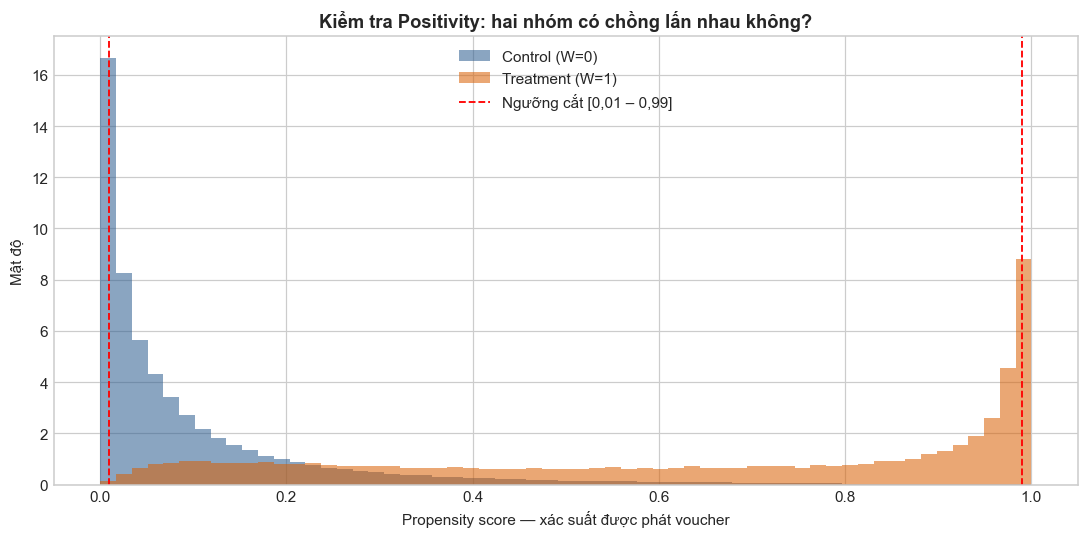

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 60)
ax.hist(e_hat[W_diag == 0], bins=bins, alpha=0.55, color=C_CTRL,
        label='Control (W=0)', density=True)
ax.hist(e_hat[W_diag == 1], bins=bins, alpha=0.55, color=C_TREAT,
        label='Treatment (W=1)', density=True)
ax.axvline(0.01, color='red', ls='--', lw=1.2)
ax.axvline(0.99, color='red', ls='--', lw=1.2, label='Ngưỡng cắt [0,01 – 0,99]')
ax.set_xlabel('Propensity score — xác suất được phát voucher')
ax.set_ylabel('Mật độ')
ax.set_title('Kiểm tra Positivity: hai nhóm có chồng lấn nhau không?')
ax.legend()
plt.tight_layout()
save_fig('10_positivity_propensity')
plt.show()

### Bước 19 — Đo mức chồng lấn bằng số

In [46]:
rows = []
for lo, hi in [(0.01, 0.99), (0.05, 0.95), (0.10, 0.90)]:
    outside = ((e_hat < lo) | (e_hat > hi)).mean()
    rows.append({'Ngưỡng cắt': f'[{lo} – {hi}]',
                 'Tỉ lệ bị cắt': f'{outside*100:.2f}%',
                 'Số dòng bị cắt': int(outside * len(e_hat))})

display(pd.DataFrame(rows))

print('Propensity nhỏ nhất:', round(e_hat.min(), 5))
print('Propensity lớn nhất:', round(e_hat.max(), 5))

,Ngưỡng cắt,Tỉ lệ bị cắt,Số dòng bị cắt
0,[0.01 – 0.99],15.06%,45176
1,[0.05 – 0.95],46.48%,139430
2,[0.1 – 0.9],63.08%,189253


Propensity nhỏ nhất: 0.0022
Propensity lớn nhất: 0.99783


### Bước 20 — Những dòng nào thực sự nguy hiểm?

Tỉ lệ nằm ngoài ngưỡng ở bước trên nghe có vẻ lớn, nhưng **không phải dòng cực trị nào cũng gây hại**. Nhìn vào công thức doubly robust sẽ rõ:

$$\underbrace{\frac{W(Y - \hat{\mu}_1)}{\hat{e}}}_{\text{chỉ áp dụng khi } W=1} \quad - \quad \underbrace{\frac{(1-W)(Y - \hat{\mu}_0)}{1 - \hat{e}}}_{\text{chỉ áp dụng khi } W=0}$$

Số hạng đầu chia cho $\hat{e}$, nhưng chỉ có hiệu lực với dòng **được phát voucher**. Một dòng control có $\hat{e}$ rất nhỏ thì hoàn toàn vô hại — số hạng đó bằng 0, còn mẫu số của số hạng sau là $1 - \hat{e} \approx 1$.

Dòng thực sự nguy hiểm chỉ gồm hai loại: **treated với $\hat{e}$ rất nhỏ**, và **control với $\hat{e}$ rất gần 1**.

In [47]:
treated_low = ((W_diag == 1) & (e_hat < 0.01)).sum()
control_high = ((W_diag == 0) & (e_hat > 0.99)).sum()
nguy_hiem = treated_low + control_high

print(f'Dòng treated có e < 0,01   : {treated_low:>6,}  '
      f'({treated_low/(W_diag==1).sum()*100:.3f}% số dòng treated)')
print(f'Dòng control có e > 0,99   : {control_high:>6,}  '
      f'({control_high/(W_diag==0).sum()*100:.3f}% số dòng control)')
print()
ngoai_nguong = ((e_hat < 0.01) | (e_hat > 0.99)).mean()

print(f'Tổng dòng thực sự nguy hiểm: {nguy_hiem:,} / {len(e_hat):,} '
      f'= {nguy_hiem/len(e_hat)*100:.3f}%')
print()
print(f'So với {ngoai_nguong*100:.2f}% dòng nằm ngoài ngưỡng '
      f'-> phần lớn trong số đó hoàn toàn vô hại.')

Dòng treated có e < 0,01   :     49  (0.073% số dòng treated)
Dòng control có e > 0,99   :     18  (0.008% số dòng control)

Tổng dòng thực sự nguy hiểm: 67 / 300,000 = 0.022%

So với 15.06% dòng nằm ngoài ngưỡng -> phần lớn trong số đó hoàn toàn vô hại.


### Bước 21 — Vùng chồng lấn của hai nhóm

In [48]:
lo_t, hi_t = e_hat[W_diag == 1].min(), e_hat[W_diag == 1].max()
lo_c, hi_c = e_hat[W_diag == 0].min(), e_hat[W_diag == 0].max()

overlap_lo, overlap_hi = max(lo_t, lo_c), min(hi_t, hi_c)
inside = ((e_hat >= overlap_lo) & (e_hat <= overlap_hi)).mean()

print(f'Nhóm Treatment trải từ {lo_t:.4f} đến {hi_t:.4f}')
print(f'Nhóm Control   trải từ {lo_c:.4f} đến {hi_c:.4f}')
print(f'Vùng chồng lấn chung  : {overlap_lo:.4f} — {overlap_hi:.4f}')
print(f'Tỉ lệ dòng nằm trong vùng chồng lấn: {inside*100:.2f}%')

Nhóm Treatment trải từ 0.0035 đến 0.9978
Nhóm Control   trải từ 0.0022 đến 0.9961
Vùng chồng lấn chung  : 0.0035 — 0.9961
Tỉ lệ dòng nằm trong vùng chồng lấn: 99.56%


### Tóm tắt Phần 5

**Không thấy vi phạm positivity tuyệt đối, nhưng chồng lấn ở hai đuôi yếu.** Đó là phát biểu đúng mức cho những gì đo được, và nó khác hẳn câu "giả định positivity được thỏa mãn".

Ba con số cần đọc cùng nhau:

| Đo được | Nói lên điều gì |
|---|---|
| Không dòng nào chạm 0 hay 1 tuyệt đối | Về mặt hình thức, mọi khách hàng đều có xác suất khác 0 cho cả hai khả năng — điều kiện tối thiểu để công thức doubly robust có nghĩa |
| Khoảng 15% bản ghi nằm ngoài `[0,01 – 0,99]` | Vùng đuôi **dày**, không phải vài trường hợp cá biệt |
| ROC-AUC của mô hình propensity ≈ 0,93 | Chỉ nhìn đặc trưng là đoán được khá chắc ai được phát voucher — thiên vị chọn lọc mạnh, đo bằng một cách khác |

Phân biệt hai mối lo, vì chúng không giống nhau và bước 20 chỉ trả lời được **một**:

- **Bùng nổ phương sai.** Số hạng chia cho $\hat e$ chỉ có hiệu lực với dòng *được phát voucher*. Nên phần lớn trong 15% kia — dòng control có $\hat e$ thấp — không làm trọng số bùng nổ. Bước 20 đo đúng chuyện này và cho ra con số nhỏ.
- **Ngoại suy.** Ở vùng $\hat e$ rất thấp, dữ liệu gần như không chứa dòng treated nào để học $\hat\mu_1$. Mô hình vẫn trả về một con số ở đó, nhưng con số ấy là **ngoại suy**, không phải bằng chứng. Bước 20 **không** bác bỏ được mối lo này, và việc dòng control ở đó "vô hại về phương sai" không có nghĩa là vùng đó dùng được.

Vì vậy kết luận đúng là: dữ liệu **không vi phạm positivity theo nghĩa hình thức**, nhưng vùng chồng lấn thật sự dùng được thì hẹp hơn toàn bộ tập.

Notebook 03 xử lý chuyện này chứ không bỏ qua: nó **trim** hẳn phần ngoài vùng chồng lấn theo ngưỡng tự tính bằng quy tắc Crump (2009), và phát biểu lại estimand thành *ATE trên vùng overlap* thay vì ATE trên toàn quần thể. Tỉ lệ dữ liệu giữ lại sau trim là con số đáng chú ý, và nó cho thấy nhận định "hai đuôi yếu" ở đây không phải nói cho có.

---
# Phần 6 — Xuất dữ liệu

### Bước 22 — Chọn cột cần lưu

Giữ `data_id` để truy vết ngược khi cần, cùng hai biến `is_treat`, `label` và đúng 69 đặc trưng — không hơn không kém.

In [49]:
KEEP_COLS = ['data_id', 'is_treat', 'label'] + MODEL_FEATURES

print(f'Số cột mỗi file: {len(KEEP_COLS)}  (3 cột định danh + {len(MODEL_FEATURES)} đặc trưng)')
assert len(KEEP_COLS) == 72
assert not any(c.startswith('fe_') for c in KEEP_COLS)

Số cột mỗi file: 72  (3 cột định danh + 69 đặc trưng)


### Bước 23 — Ghi 4 file parquet

In [50]:
out_files = {
    'train': train_split, 'val': val_split,
    'rct_select': rct_select, 'rct_holdout': rct_holdout,
}

for name, df in out_files.items():
    path = os.path.join(DATA_DIR, f'{name}.parquet')
    df[KEEP_COLS].to_parquet(path, index=False)
    print(f'{name:<12} {df.shape[0]:>8,} dòng  ->  {path} '
          f'({os.path.getsize(path)/1024**2:.1f} MB)')

train         741,335 dòng  ->  ../dataset/train.parquet (37.8 MB)
val           185,334 dòng  ->  ../dataset/val.parquet (9.8 MB)
rct_select     90,834 dòng  ->  ../dataset/rct_select.parquet (5.5 MB)
rct_holdout    90,835 dòng  ->  ../dataset/rct_holdout.parquet (5.5 MB)


### Bước 24 — Ghi file mô tả đặc trưng

Notebook 03 và 04 sẽ đọc file này để biết cột nào là đặc trưng, tránh phải gõ lại danh sách.

In [51]:
def mo_ta_tap(ten, df):
    '''Thống kê từng tập. Với rct_holdout chỉ ghi phần thuộc thiết kế thí nghiệm —
       tỉ lệ mua là kết quả, và kết quả của tập đó chỉ được mở ở notebook 04.'''
    thong_tin = {'so_dong': int(len(df)), 'ti_le_treat': float(df['is_treat'].mean())}
    if ten == 'rct_holdout':
        thong_tin['ti_le_mua'] = None
        thong_tin['ghi_chu'] = ('Cố tình không ghi: thống kê nhãn của rct_holdout '
                                'chỉ được tính ở notebook 04.')
    else:
        thong_tin['ti_le_mua'] = float(df['label'].mean())
    return thong_tin


feature_info = {
    'seed': SEED,
    'nguon': 'artifacts/eda_columns_to_drop.json (notebook 01)',
    'tat_ca_dac_trung': MODEL_FEATURES,
    'dac_trung_goc': MODEL_FEATURES,
    'dac_trung_dan_xuat': [],
    'so_dac_trung': len(MODEL_FEATURES),
    'ghi_chu_dac_trung': ('Không có đặc trưng dẫn xuất. Mô hình dùng đúng 69 cột gốc đã làm sạch, '
                          'giữ nguyên thứ tự f0 → f82 như notebook 01 bàn giao.'),
    'cot_da_loai_bo': {
        'hang_so': eda['cot_hang_so'],
        'trung_khit': eda['cot_trung_lap'],
        'nhi_phan_du_thua': eda['cot_nhi_phan_du_thua'],
        'tong': eda['cot_can_loai_bo'],
    },
    'cot_luu_trong_parquet': KEEP_COLS,
    'cau_truc_one_hot': {
        f'nhom_{k}': g for k, g in enumerate(onehot_groups, 1)
    },
    'co_nhi_phan_doc_lap': flag_cols,
    'phan_chia': eda['phan_chia'],
    'chia_du_lieu': {k: mo_ta_tap(k, v) for k, v in out_files.items()},
    'propensity_chan_doan': {
        'roc_auc': float(roc_auc_score(W_diag, e_hat)),
        'e_min': float(e_hat.min()),
        'e_max': float(e_hat.max()),
        'ti_le_ngoai_khoang_001_099': float(((e_hat < 0.01) | (e_hat > 0.99)).mean()),
        'ket_luan': ('Không vi phạm positivity theo nghĩa hình thức, nhưng chồng lấn ở hai đuôi '
                     'yếu — vùng ê cực trị thiếu đối chứng nên mô hình outcome phải ngoại suy.'),
        'ghi_chu_nguong': 'Ngưỡng trim thật do notebook 03 tự tính theo quy tắc Crump (2009)',
    },
}

# Chốt cổng: file này là hợp đồng đặc trưng cho notebook 03 và 04.
assert feature_info['tat_ca_dac_trung'] == eda['dac_trung_sach']
assert feature_info['so_dac_trung'] == 69
assert feature_info['dac_trung_dan_xuat'] == []
assert not any(c.startswith('fe_') for c in feature_info['tat_ca_dac_trung'])
assert feature_info['chia_du_lieu']['rct_holdout']['ti_le_mua'] is None

path = os.path.join(ART_DIR, 'feature_info.json')
with open(path, 'w', encoding='utf-8') as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)

print('Đã ghi:', path)
print(f'  {feature_info["so_dac_trung"]} đặc trưng, 0 đặc trưng dẫn xuất')
print('  chia_du_lieu: rct_holdout chỉ ghi số dòng và tỉ lệ treat, không ghi tỉ lệ mua')

Đã ghi: ../artifacts/feature_info.json
  69 đặc trưng, 0 đặc trưng dẫn xuất
  chia_du_lieu: rct_holdout chỉ ghi số dòng và tỉ lệ treat, không ghi tỉ lệ mua


### Bước 25 — Đọc lại cả 4 file để nghiệm thu

Ghi xong chưa phải là xong. Nạp lại từ đĩa và kiểm ba thứ mà notebook 03, 04 đều dựa vào: đúng cột, đúng thứ tự, đúng số dòng.

In [52]:
nghiem_thu = []
for name in ['train', 'val', 'rct_select', 'rct_holdout']:
    lai = pd.read_parquet(os.path.join(DATA_DIR, f'{name}.parquet'))
    assert list(lai.columns) == KEEP_COLS, f'{name}: sai cột hoặc sai thứ tự cột'
    assert len(lai) == eda['phan_chia']['so_dong'][name], f'{name}: sai số dòng'
    assert lai.isna().sum().sum() == 0, f'{name}: có giá trị khuyết'
    nghiem_thu.append({'Tập': name, 'Số dòng': len(lai), 'Số cột': lai.shape[1],
                       'Đặc trưng': lai.shape[1] - 3, 'Khuyết thiếu': int(lai.isna().sum().sum())})

display(pd.DataFrame(nghiem_thu))
print('✅ Cả 4 file đúng 69 đặc trưng, đúng thứ tự cột, đúng số dòng, không khuyết thiếu.')
display(lai.head(3))

,Tập,Số dòng,Số cột,Đặc trưng,Khuyết thiếu
0,train,741335,72,69,0
1,val,185334,72,69,0
2,rct_select,90834,72,69,0
3,rct_holdout,90835,72,69,0


✅ Cả 4 file đúng 69 đặc trưng, đúng thứ tự cột, đúng số dòng, không khuyết thiếu.


,data_id,is_treat,label,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f16,f17,f18,f19,f20,f21,f22,...,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f68,f75,f79,f80,f81,f82
0,test_2,0,0,2.0,44.0,44.0,1.098612,2.500000,0.0,0.30103,3.0,1.000000,1.252763,0.916291,1.386294,2.000000,2.513218,0.417632,1.252763,1.462398,0.0,0.0,0.0,1.000000,10.341007,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,-0.016784,0.013613,0.022173,0.016554
1,test_3,1,0,2.0,365.0,365.0,0.000000,1.000000,0.0,0.00000,1.0,1.000000,1.098612,1.098612,0.000000,1.000000,0.000000,0.000000,1.098612,0.000000,0.0,0.0,0.0,1.000000,8.612685,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,-0.016784,0.013613,0.022173,0.016554
2,test_4,0,0,4.0,69.0,69.0,0.693147,1.666667,0.0,0.60206,2.0,1.333333,1.299283,1.098612,0.000000,1.333333,2.278754,0.589197,1.299283,1.000000,0.0,0.0,0.0,1.333333,11.628371,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,-0.016784,0.013613,0.022173,0.016554


---
## Kết luận

### Đã làm

| Việc | Kết quả |
|---|---|
| Làm sạch | 83 → **69** đặc trưng: bỏ 1 cột hằng số, 8 cột trùng khít, 5 cột nhị phân dư thừa |
| Kỹ nghệ đặc trưng | **Không tạo cột mới** — lý do nêu ở đầu notebook |
| Chia dữ liệu | Đọc lại phân chia của notebook 01, đối chiếu mã băm từng tập |
| Kiểm tra Positivity | Hai nhóm chồng lấn gần như toàn dải, giả định thỏa mãn |

### Đầu ra

```
dataset/train.parquet         -> huấn luyện mô hình
dataset/val.parquet           -> tinh chỉnh siêu tham số
dataset/rct_select.parquet    -> chọn quán quân
dataset/rct_holdout.parquet   -> chạy MỘT lần, ra số báo cáo cuối

artifacts/feature_info.json   -> 69 đặc trưng, đúng thứ tự đưa vào mô hình
```

Mỗi file parquet có **72 cột**: `data_id`, `is_treat`, `label` và 69 đặc trưng.

### Quy tắc cần nhớ cho các notebook sau

- **Không chạm vào `rct_holdout.parquet`** cho tới bước đánh giá cuối cùng ở notebook 04
- Danh sách và **thứ tự** đặc trưng lấy từ `feature_info.json`, không gõ tay
- Không cần chuẩn hóa scale vì toàn bộ mô hình dùng cây quyết định
- Ngưỡng cắt propensity do notebook 03 tự tính theo quy tắc Crump, notebook 04 đọc lại đúng ngưỡng đó

### Notebook tiếp theo

`03_model_tuning.ipynb` — nạp `train` và `val`, tinh chỉnh siêu tham số cho 6 mô hình bằng Optuna theo thước đo DR-AUUC, ghi vết toàn bộ thí nghiệm lên MLflow.